# Plot TRPO Training Results

In [7]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

%matplotlib inline

In [8]:
log_dir = 'runs/trpo/20260304_234405'

event_acc = EventAccumulator(log_dir)
event_acc.Reload()

tags = event_acc.Tags()['scalars']
print(f"Found tags: {tags}")

Found tags: ['train/mean_return', 'train/mean_steps', 'train/surrogate_loss', 'train/kl_divergence', 'train/adv_abs_mean', 'train/adv_std']


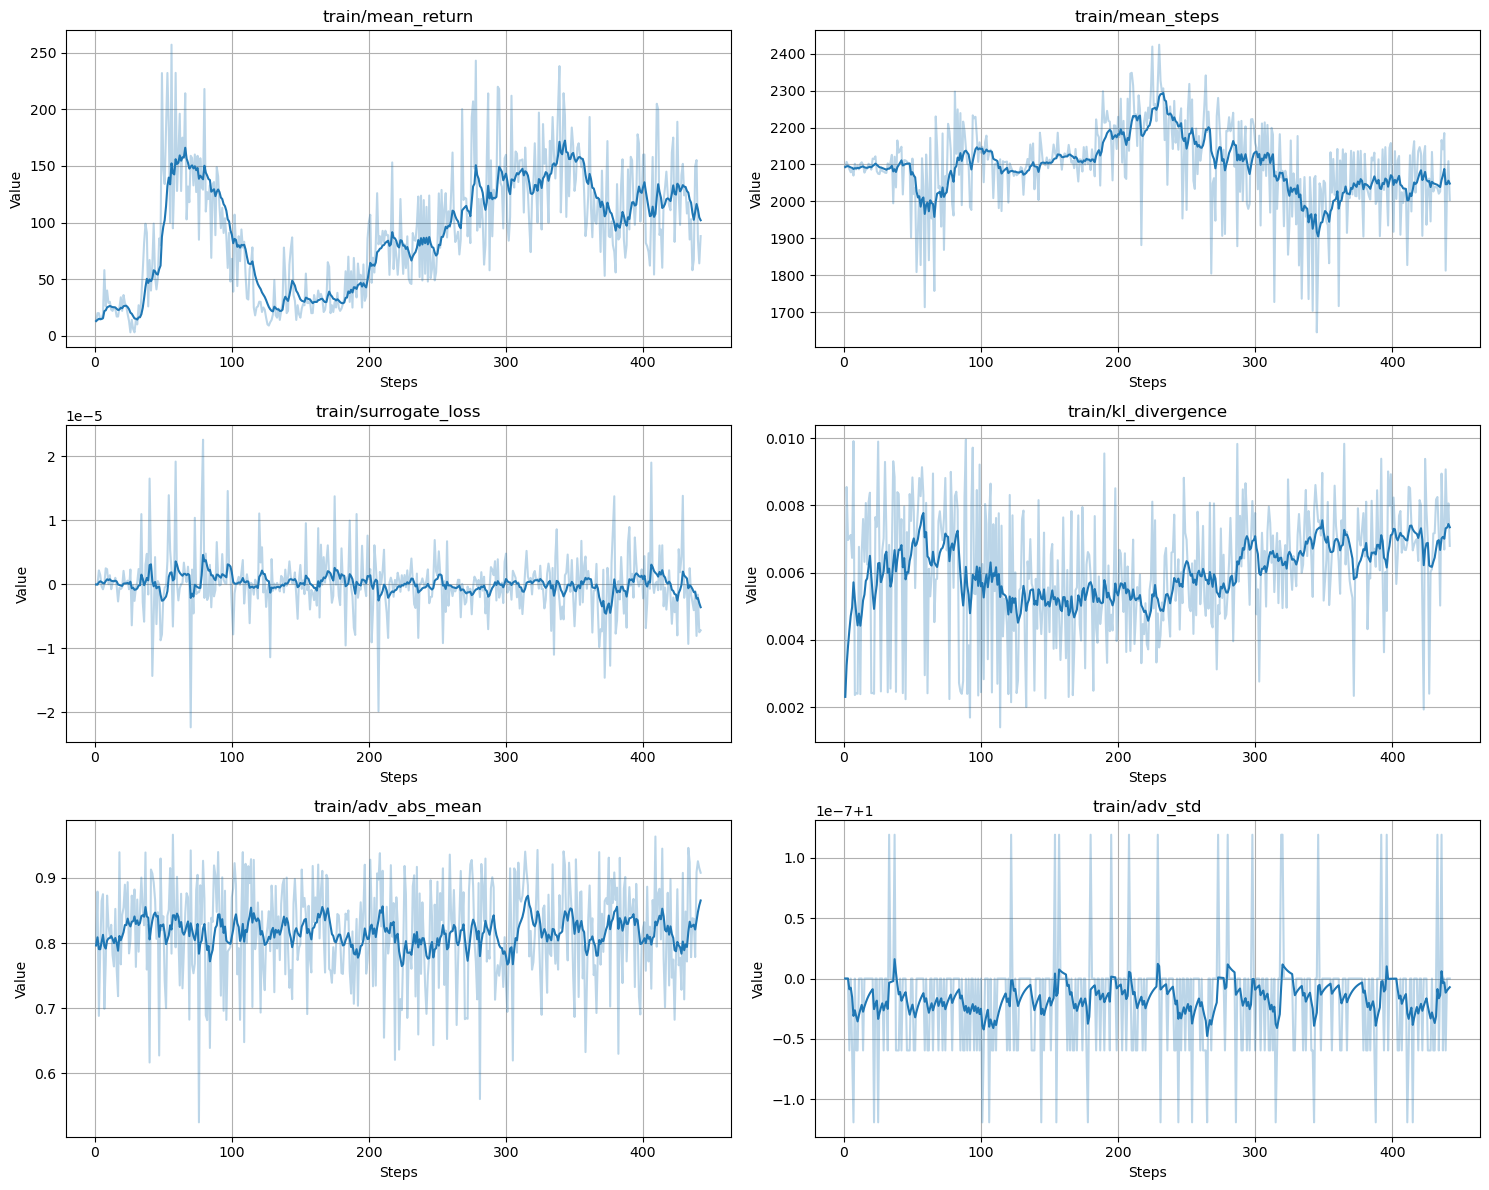

In [9]:
if tags:
    n_tags = len(tags)
    cols = 2
    rows = (n_tags + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    if n_tags == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
        
    for i, tag in enumerate(tags):
        events = event_acc.Scalars(tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        
        ax = axes[i]
        alpha = 0.85
        smoothed_values = []
        if values:
            last = values[0]
            for v in values:
                smoothed_val = last * alpha + (1 - alpha) * v
                smoothed_values.append(smoothed_val)
                last = smoothed_val
        
        line, = ax.plot(steps, values, alpha=0.3)
        ax.plot(steps, smoothed_values, color=line.get_color())
        ax.set_title(tag)
        ax.set_xlabel("Steps")
        ax.set_ylabel("Value")
        ax.grid(True)
        
    # Hide any unused subplots
    for j in range(len(tags), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
else:
    print("No scalar tags found.")